In [1]:
!pip install torch torchvision pandas scikit-learn matplotlib seaborn kaggle

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7/7 [kaggle]2m5/7 [jupytext]]


In [3]:
import os

os.environ['KAGGLE_USERNAME'] = "hamzabelkadietu"
os.environ['KAGGLE_KEY'] = "KGAT_3f42b81bbf1957bdf5bed479ec0ac3a4"

In [4]:
!kaggle datasets download -d nih-chest-xrays/data

Dataset URL: https://www.kaggle.com/datasets/nih-chest-xrays/data
License(s): CC0-1.0
100%|███████████████████████████████████████| 42.0G/42.0G [04:17<00:00, 175MB/s]



In [5]:
!unzip -q data.zip

In [6]:
import torch
import torch.nn as nn
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from PIL import Image
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms as transforms
import torchvision.models as models

import pytorch_lightning as pl
import torchmetrics

from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_curve, auc, confusion_matrix

In [7]:
# =========================
# PREPARE DATA
# =========================
df = pd.read_csv("Data_Entry_2017.csv")

labels = [
    'Atelectasis','Cardiomegaly','Effusion','Infiltration',
    'Mass','Nodule','Pneumonia','Pneumothorax',
    'Consolidation','Edema','Emphysema','Fibrosis',
    'Pleural_Thickening','Hernia'
]

def encode(x):
    return [1 if l in x else 0 for l in labels]

df['target'] = df['Finding Labels'].apply(encode)

# Reduce dataset (important)
df = df.sample(8000)

train_df, val_df = train_test_split(df, test_size=0.2)

In [8]:
# =========================
# DATASET
# =========================
transform = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.ToTensor()
])

class XrayDataset(Dataset):
    def __init__(self, df):
        self.df = df
        self.img_dirs = [f"images_{str(i).zfill(3)}/images" for i in range(1,13)]

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        img_name = self.df.iloc[idx]['Image Index']
        label = torch.tensor(self.df.iloc[idx]['target'], dtype=torch.float)

        img_path = None
        for d in self.img_dirs:
            path = os.path.join(d, img_name)
            if os.path.exists(path):
                img_path = path
                break

        image = Image.open(img_path).convert("RGB")
        image = transform(image)

        return image, label

train_loader = DataLoader(XrayDataset(train_df), batch_size=32, shuffle=True)
val_loader = DataLoader(XrayDataset(val_df), batch_size=32)

In [9]:
# =========================
# MODEL
# =========================
class PneumoModel(pl.LightningModule):
    def __init__(self):
        super().__init__()

        self.model = models.resnet50(pretrained=True)
        self.model.fc = nn.Linear(self.model.fc.in_features, 14)

        self.loss_fn = nn.BCEWithLogitsLoss()

        self.f1 = torchmetrics.F1Score(task="multilabel", num_labels=14)
        self.auroc = torchmetrics.AUROC(task="multilabel", num_labels=14)

        self.train_losses = []
        self.val_losses = []

        self.all_preds = []
        self.all_targets = []

    def forward(self, x):
        return self.model(x)

    def training_step(self, batch, batch_idx):
        x, y = batch
        y_hat = self(x)

        loss = self.loss_fn(y_hat, y)
        self.train_losses.append(loss.item())

        return loss

    def validation_step(self, batch, batch_idx):
        x, y = batch
        y_hat = self(x)

        loss = self.loss_fn(y_hat, y)
        preds = torch.sigmoid(y_hat)

        self.val_losses.append(loss.item())

        self.all_preds.append(preds.cpu().detach())
        self.all_targets.append(y.cpu().detach())

        self.log("val_f1", self.f1(preds, y.int()))
        self.log("val_auc", self.auroc(preds, y.int()))

    def configure_optimizers(self):
        return torch.optim.Adam(self.parameters(), lr=1e-4)

In [10]:
# =========================
# TRAIN
# =========================
model = PneumoModel()

trainer = pl.Trainer(
    accelerator="gpu" if torch.cuda.is_available() else "cpu",
    devices=1,
    max_epochs=5
)

trainer.fit(model, train_loader, val_loader)

/home/zeus/miniconda3/envs/cloudspace/lib/python3.12/site-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/home/zeus/miniconda3/envs/cloudspace/lib/python3.12/site-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet50_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet50_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Downloading: "https://download.pytorch.org/models/resnet50-0676ba61.pth" to /teamspace/studios/this_studio/.cache/torch/hub/checkpoints/resnet50-0676ba61.pth


100%|██████████| 97.8M/97.8M [00:00<00:00, 158MB/s]
💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


┏━━━┳━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━┳━━━━━━━┓
┃   ┃ Name    ┃ Type              ┃ Params ┃ Mode  ┃ FLOPs ┃
┡━━━╇━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━╇━━━━━━━┩
│ 0 │ model   │ ResNet            │ 23.5 M │ train │     0 │
│ 1 │ loss_fn │ BCEWithLogitsLoss │      0 │ train │     0 │
│ 2 │ f1      │ MultilabelF1Score │      0 │ train │     0 │
│ 3 │ auroc   │ MultilabelAUROC   │      0 │ train │     0 │
└───┴─────────┴───────────────────┴────────┴───────┴───────┘

Trainable params: 23.5 M                                                                                           
Non-trainable params: 0                                                                                            
Total params: 23.5 M                                                                                               
Total estimated model params size (MB): 94                                                                         
Modules in train mode: 154                                                                                         
Modules in eval mode: 0                                                                                            
Total FLOPs: 0

Output()

/home/zeus/miniconda3/envs/cloudspace/lib/python3.12/site-packages/pytorch_lightning/trainer/connectors/data_connec
tor.py:434: The 'val_dataloader' does not have many workers which may be a bottleneck. Consider increasing the 
value of the `num_workers` argument` to `num_workers=3` in the `DataLoader` to improve performance.

/home/zeus/miniconda3/envs/cloudspace/lib/python3.12/site-packages/torchmetrics/utilities/prints.py:43: 
UserWarning: No positive samples in targets, true positive value should be meaningless. Returning zero tensor in 
true positive score
  warnings.warn(*args, **kwargs)

/home/zeus/miniconda3/envs/cloudspace/lib/python3.12/site-packages/pytorch_lightning/trainer/connectors/data_connec
tor.py:434: The 'train_dataloader' does not have many workers which may be a bottleneck. Consider increasing the 
value of the `num_workers` argument` to `num_workers=3` in the `DataLoader` to improve performance.

`Trainer.fit` stopped: `max_epochs=5` reached.


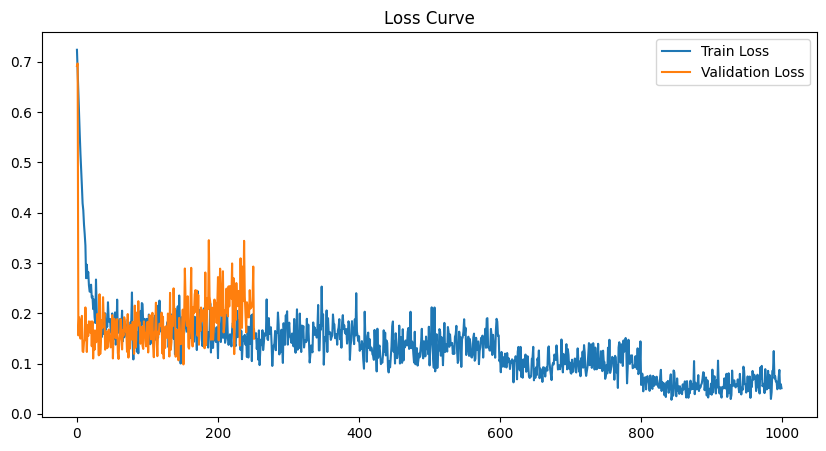

In [11]:
# =========================
# 📊 GRAPHS
# =========================

# LOSS CURVE
plt.figure(figsize=(10,5))
plt.plot(model.train_losses, label="Train Loss")
plt.plot(model.val_losses, label="Validation Loss")
plt.legend()
plt.title("Loss Curve")
plt.show()

In [12]:
# =========================
# PREPARE PREDICTIONS
# =========================
preds = torch.cat(model.all_preds).numpy()
targets = torch.cat(model.all_targets).numpy()

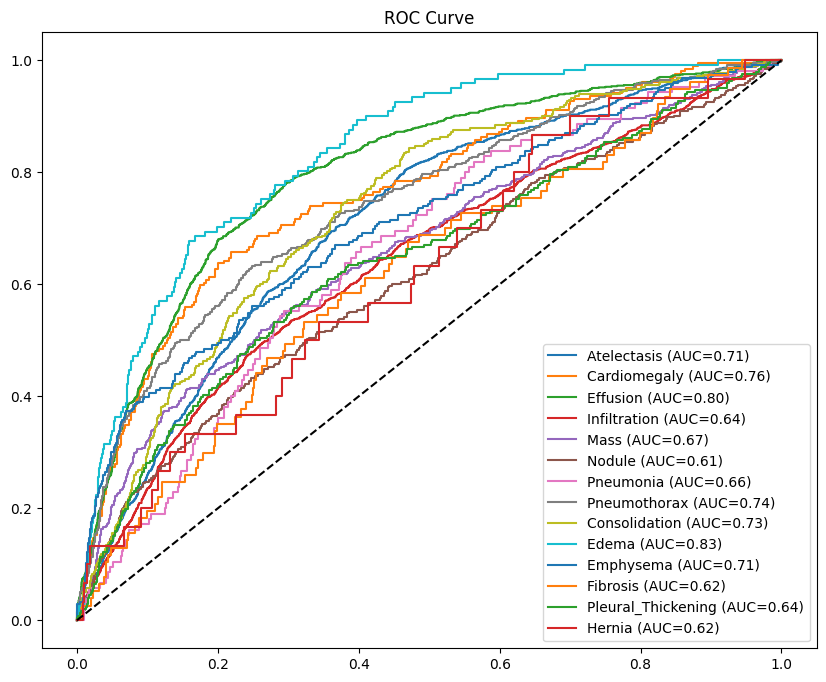

In [13]:
# =========================
# ROC CURVE
# =========================
plt.figure(figsize=(10,8))
for i in range(14):
    fpr, tpr, _ = roc_curve(targets[:, i], preds[:, i])
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, label=f"{labels[i]} (AUC={roc_auc:.2f})")

plt.plot([0,1],[0,1],'k--')
plt.title("ROC Curve")
plt.legend()
plt.show()

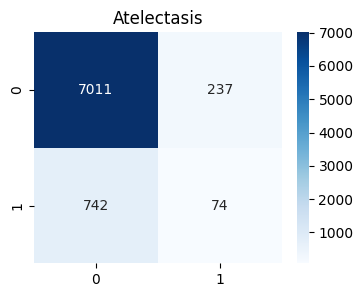

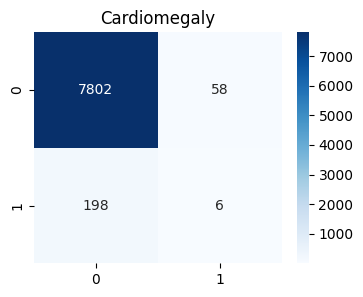

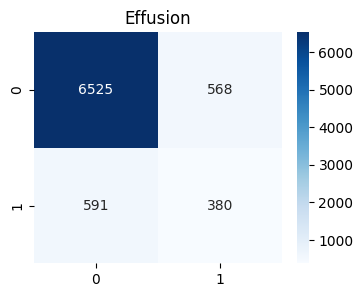

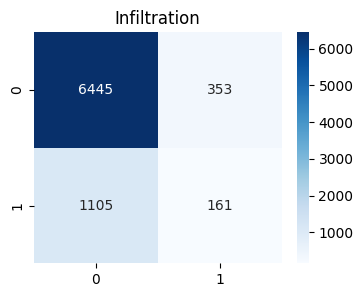

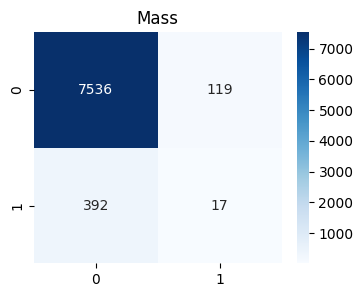

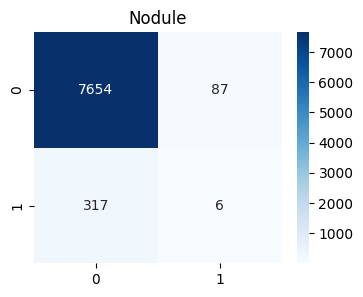

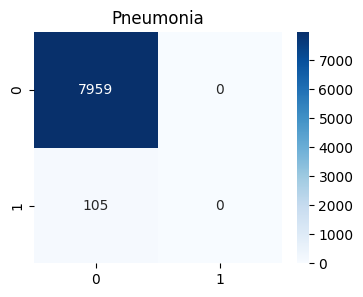

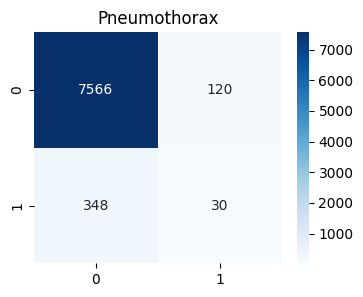

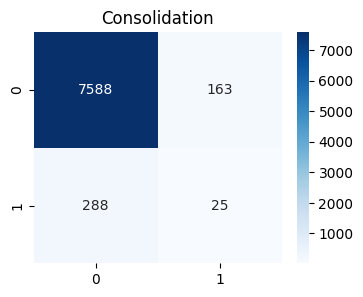

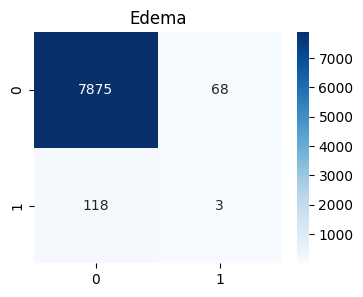

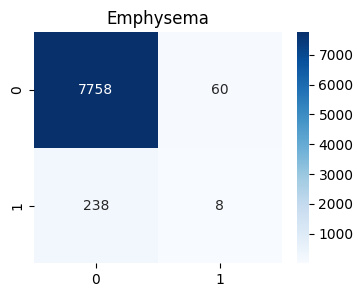

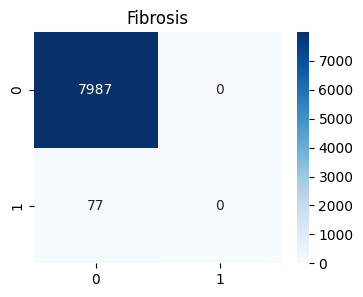

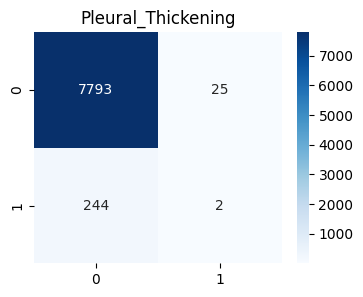

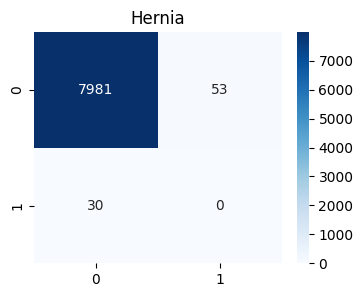

In [18]:
# =========================
# CONFUSION MATRIX
# =========================
for i in range(14):  # show only 3 to avoid overload
    cm = confusion_matrix(targets[:, i], preds[:, i] > 0.5)

    plt.figure(figsize=(4,3))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
    plt.title(labels[i])
    plt.show()

In [15]:
# Save only weights
torch.save(model.model.state_dict(), "model_weights.pth")
# Load only weights
model = models.resnet50(pretrained=False)
model.fc = nn.Linear(model.fc.in_features, 14)

model.load_state_dict(torch.load("model_weights.pth"))
model.eval()

/home/zeus/miniconda3/envs/cloudspace/lib/python3.12/site-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/home/zeus/miniconda3/envs/cloudspace/lib/python3.12/site-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=None`.
  warnings.warn(msg)


ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): Bottleneck(
      (conv1): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (conv3): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (bn3): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (downsample): Sequential(
        (0): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 

In [22]:
# Save full model (architecture + weights)
torch.save(model, "full_model.pth")
# Load full model (architecture + weights)
model = torch.load("full_model.pth", weights_only=False)
model.eval()

PneumoModel(
  (model): ResNet(
    (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
    (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (relu): ReLU(inplace=True)
    (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
    (layer1): Sequential(
      (0): Bottleneck(
        (conv1): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
        (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (conv3): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 1), bias=False)
        (bn3): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (relu): ReLU(inplace=True)
        (downsample): Sequential(
        

In [20]:
# Save Lightning checkpoint (BEST)
trainer.save_checkpoint("final_model.ckpt")
# Load Lightning checkpoint (BEST)
model = PneumoModel.load_from_checkpoint("final_model.ckpt")
model.eval()

`weights_only` was not set, defaulting to `False`.
/home/zeus/miniconda3/envs/cloudspace/lib/python3.12/site-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/home/zeus/miniconda3/envs/cloudspace/lib/python3.12/site-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet50_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet50_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


PneumoModel(
  (model): ResNet(
    (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
    (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (relu): ReLU(inplace=True)
    (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
    (layer1): Sequential(
      (0): Bottleneck(
        (conv1): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
        (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (conv3): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 1), bias=False)
        (bn3): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (relu): ReLU(inplace=True)
        (downsample): Sequential(
        